# Passenger mutability and the distribution of phenotypic effects of mutations

Compare the distribution of affinity and expression effects under two models:
- **Uniform**: every single-nucleotide nonsynonymous change is equally likely
- **Passenger**: each change is weighted by its empirical rate from chIgy passenger sequences

Mutation rates come from the precomputed `mutations_csv` (same source as `affinity-fitness-response.ipynb`).

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
mutations_csv = "../results/notebooks/mutations/naive_reversions_first/data.csv"

muts = (
    pd.read_csv(mutations_csv)
    .query("single_nt == True and mutant != wildtype and mutant != '*'")
    [["delta_bind_CGG", "delta_expr", "mutation rate"]]
    .dropna()
    .rename(columns={"mutation rate": "passenger_rate"})
    .reset_index(drop=True)
)

muts["weight_uniform"] = 1.0 / len(muts)
muts["weight_passenger"] = muts["passenger_rate"] / muts["passenger_rate"].sum()

print(f"{len(muts)} single-nt nonsynonymous mutations")
muts.head(3)

1275 single-nt nonsynonymous mutations


,delta_bind_CGG,delta_expr,passenger_rate,weight_uniform,weight_passenger
0,0.11933,-0.00246,0.000006,0.000784,0.000004
1,0.01249,0.04874,0.000725,0.000784,0.000491
2,0.20009,-0.02445,0.000006,0.000784,0.000004


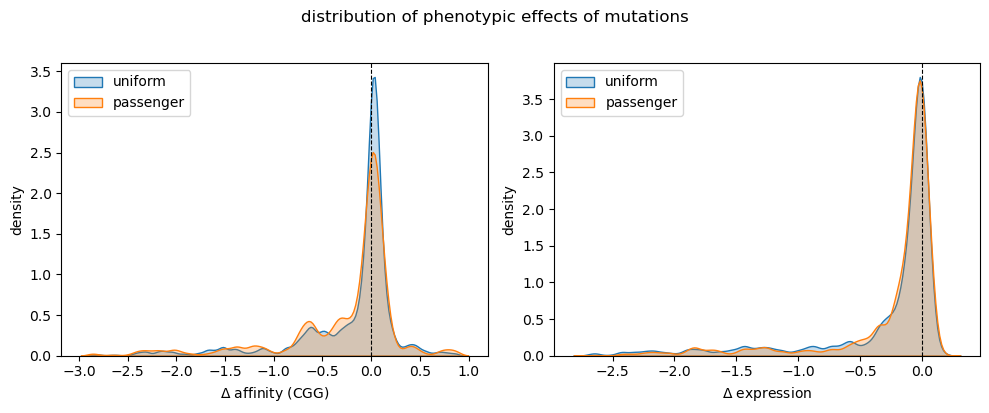

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, pheno, label in [
    (axes[0], "delta_bind_CGG", r"$\Delta$ affinity (CGG)"),
    (axes[1], "delta_expr", r"$\Delta$ expression"),
]:
    for wt_col, lbl in [
        ("weight_uniform", "uniform"),
        ("weight_passenger", "passenger"),
    ]:
        sns.kdeplot(
            data=muts,
            x=pheno,
            weights=wt_col,
            ax=ax,
            label=lbl,
            # color=color,
            linewidth=1,
            fill=True,
            alpha=0.25,
            bw_adjust=0.3,
        )
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_xlabel(label)
    ax.set_ylabel("density")
    ax.legend()

plt.suptitle("distribution of phenotypic effects of mutations", y=1.02)
plt.tight_layout()
plt.savefig("output/passenger-dfe/kde_bind_expr.pdf", bbox_inches="tight")
plt.show()

In [24]:
print("Weighted means:")
for pheno in ["delta_bind_CGG", "delta_expr"]:
    mu_u = np.average(muts[pheno], weights=muts["weight_uniform"])
    mu_p = np.average(muts[pheno], weights=muts["weight_passenger"])
    print(f"  {pheno:<15}: uniform={mu_u:.4f}, passenger={mu_p:.4f}")

Weighted means:
  delta_bind_CGG : uniform=-0.2038, passenger=-0.2656
  delta_expr     : uniform=-0.3016, passenger=-0.2527
